# Mark 4B — ROI Probability Calibration and Failure Diagnostics

## tl;dr

Mark 4 improved mean patient Dice, V104/V116 recovery, and Q1 detection, but narrowly
missed the temporary positive-empty gate. This validation-only notebook determines whether
the epoch-5 model already contains useful sub-0.50 tumor probabilities or whether another
training change is required.

It performs one deterministic validation inference pass, caches full-image probabilities,
evaluates one global threshold grid, inspects focus-patient localization and population
separation, bootstraps patient uncertainty, and writes the next decision.

No training occurs. No patient-specific threshold is allowed. The test split remains locked.

## Context & Methods

### Key assumptions

- `mark_4_best.pth` is the frozen epoch-5 smoke checkpoint.
- Validation ROIs use the frozen Mark 2/3 prediction-only rule.
- Probabilities are mapped to full 256×256 coordinates before evaluation.
- One threshold is applied to every validation patient.
- Ground truth is used only for metrics, grouping, and diagnostic plots.
- Configuration selection uses validation data and must be frozen before later test access.

### Preregistered threshold grid

`0.05, 0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.70`

### Decision order

1. Prefer a configuration passing every temporary continuation target.
2. Within passing configurations, maximize mean patient Dice and then minimize empty-slice FP.
3. If none passes, report the maximum number of targets passed and diagnose the failure.
4. Never select separate thresholds for V104, V116, or lesion-size groups.

In [1]:
from __future__ import annotations

from pathlib import Path
from IPython.display import display
import hashlib
import json
import random
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
DATASET_ROOT = Path(
    r"D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging"
    r"\build_corrected_20260713_214847_v2"
)
MANIFEST_PATH = DATASET_ROOT / "manifests" / "slice_manifest.csv"
MARK4_DIR = PROJECT_ROOT / "mark 1" / "mark_4_outputs"
CHECKPOINT_PATH = MARK4_DIR / "mark_4_best.pth"
MARK4_GATE_PATH = MARK4_DIR / "mark_4_gate_result.json"
VALIDATION_ROI_PATH = MARK4_DIR / "validation_roi_manifest.csv"
OUTPUT_DIR = PROJECT_ROOT / "mark 1" / "mark_4b_outputs"
CACHE_DIR = OUTPUT_DIR / "probability_cache"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

EXPECTED_MANIFEST_SHA256 = (
    "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
)
EXPECTED_SOURCE_CHECKPOINT_SHA256 = (
    "9c4160bbd68891f9dc4e5f04ceca4391f38c5869b3f81c72b95d4639e0572223"
)
SEED = 42
BATCH_SIZE = 8
NUM_WORKERS = 0
ROI_SIZE = 256
REBUILD_CACHE = False
THRESHOLDS = np.array(
    [0.05, 0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45,
     0.50, 0.55, 0.60, 0.70], dtype=np.float32
)
BOOTSTRAP_ITERATIONS = 1_000
CONTINUATION_TARGETS = {
    "mean_patient_dice": 0.3329,
    "volume_104_dice": 0.05,
    "volume_116_dice": 0.01,
    "q1_detected_pct": 35.0,
    "positive_predicted_empty_pct": 35.0,
    "empty_slice_false_positive_pct": 20.0,
}
FINAL_TARGETS = {
    "mean_patient_dice": 0.406915,
    "volume_104_dice": 0.50,
    "volume_116_dice": 0.05,
    "q1_detected_pct": 45.0,
    "positive_predicted_empty_pct": 20.0,
    "empty_slice_false_positive_pct": 15.0,
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Outputs: {OUTPUT_DIR}")

Device: cuda | Outputs: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\mark 1\mark_4b_outputs


## Data

### 1. Verify checkpoint, Mark 4 evidence, and test lock

In [2]:
from src.framework.data.manifest_dataset import VerifiedManifestDataset
from src.framework.models.mobilenetv2_unet import MobileNetV2UNet

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()

assert sha256_file(MANIFEST_PATH) == EXPECTED_MANIFEST_SHA256
mark4_gate = json.loads(MARK4_GATE_PATH.read_text())
assert mark4_gate["status"] == "mark_4_smoke_fail"
assert mark4_gate["best_epoch"] == 5
assert mark4_gate["test_images_accessed"] is False

checkpoint_hash = sha256_file(CHECKPOINT_PATH)
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
assert checkpoint["epoch"] == 5
assert checkpoint["manifest_sha256"] == EXPECTED_MANIFEST_SHA256
assert checkpoint["source_checkpoint_sha256"] == EXPECTED_SOURCE_CHECKPOINT_SHA256

manifest = pd.read_csv(MANIFEST_PATH)
validation_manifest = (
    manifest.loc[manifest["split"].eq("val")]
    .sort_values(["volume_id", "slice_index"]).reset_index(drop=True)
)
assert len(validation_manifest) == 10_685
try:
    VerifiedManifestDataset(MANIFEST_PATH, split="test", root_dir=DATASET_ROOT)
except PermissionError:
    pass
else:
    raise AssertionError("STOP: test split opened without authorization.")

validation_rois = pd.read_csv(VALIDATION_ROI_PATH)
assert len(validation_rois) == 13
assert not validation_rois["roi_empty"].astype(bool).any()

provenance = {
    "manifest_sha256": EXPECTED_MANIFEST_SHA256,
    "mark4_checkpoint_path": str(CHECKPOINT_PATH),
    "mark4_checkpoint_sha256": checkpoint_hash,
    "mark4_checkpoint_epoch": int(checkpoint["epoch"]),
    "source_checkpoint_sha256": EXPECTED_SOURCE_CHECKPOINT_SHA256,
    "thresholds": THRESHOLDS.tolist(),
    "validation_slices": int(len(validation_manifest)),
    "validation_patients": int(validation_manifest["volume_id"].nunique()),
    "test_images_accessed": False,
}
(OUTPUT_DIR / "mark_4b_provenance.json").write_text(
    json.dumps(provenance, indent=2), encoding="utf-8"
)
print("PASS: checkpoint, validation population, ROI manifest, and test lock verified.")

PASS: checkpoint, validation population, ROI manifest, and test lock verified.


### 2. Build the frozen validation ROI dataset and load the model

In [3]:
def resize_float(array, size=(ROI_SIZE, ROI_SIZE)):
    return np.asarray(
        Image.fromarray(array.astype(np.float32), mode="F").resize(
            size, Image.Resampling.BILINEAR
        ), dtype=np.float32,
    )

class ValidationROIDataset(Dataset):
    def __init__(self, rows, rois):
        self.rows = rows.reset_index(drop=True)
        self.rois = rois.set_index("volume_id")
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, index):
        row = self.rows.iloc[index]
        roi = self.rois.loc[int(row.volume_id)]
        y0, y1, x0, x1 = [int(roi[key]) for key in ("y0", "y1", "x0", "x1")]
        with Image.open(DATASET_ROOT / row.image_path) as handle:
            image = np.asarray(handle.convert("L"), dtype=np.float32) / 255.0
        image_roi = resize_float(image[y0:y1, x0:x1])
        return {
            "image": torch.from_numpy(image_roi[None]).float(),
            "sample_id": str(row.sample_id),
            "volume_id": int(row.volume_id),
            "slice_index": int(row.slice_index),
            "box": torch.tensor([y0, y1, x0, x1], dtype=torch.int32),
        }

dataset = ValidationROIDataset(validation_manifest, validation_rois)
loader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
model = MobileNetV2UNet(in_channels=1, out_channels=1, pretrained=False)
model.load_state_dict(checkpoint["model_state"], strict=True)
model.to(device).eval()
with torch.inference_mode():
    probe = torch.sigmoid(model(torch.zeros(1, 1, 256, 256, device=device)))
assert probe.shape == (1, 1, 256, 256)
assert torch.isfinite(probe).all()
print("PASS: frozen ROI model and ordered validation loader ready.")

PASS: frozen ROI model and ordered validation loader ready.


### 3. Run validation inference once and cache full-image probabilities by patient

In [4]:
def probability_to_full(probability_roi, box):
    y0, y1, x0, x1 = [int(value) for value in box]
    resized = np.asarray(
        Image.fromarray(probability_roi.astype(np.float32), mode="F").resize(
            (x1 - x0, y1 - y0), Image.Resampling.BILINEAR
        ), dtype=np.float32,
    )
    full = np.zeros((256, 256), dtype=np.float32)
    full[y0:y1, x0:x1] = resized
    return full

def save_volume(volume_id, bucket):
    order = np.argsort(bucket["slice_index"])
    np.savez_compressed(
        CACHE_DIR / f"volume_{volume_id}.npz",
        **{key: np.asarray(value)[order] for key, value in bucket.items()},
    )

def build_cache():
    current_volume = None
    bucket = None
    processed = []
    with torch.inference_mode():
        for batch in loader:
            probabilities = torch.sigmoid(
                model(batch["image"].to(device, non_blocking=True))
            ).cpu().numpy()[:, 0]
            for index, sample_id in enumerate(batch["sample_id"]):
                volume_id = int(batch["volume_id"][index])
                if current_volume is None or volume_id != current_volume:
                    if current_volume is not None:
                        save_volume(current_volume, bucket)
                        processed.append(current_volume)
                        print(f"Cached volume {current_volume}")
                    current_volume = volume_id
                    bucket = {
                        "sample_id": [], "slice_index": [],
                        "tumor_probability": [], "tumor_truth": [],
                    }
                probability_full = probability_to_full(
                    probabilities[index], batch["box"][index].numpy()
                )
                row = validation_manifest.loc[
                    validation_manifest["sample_id"].eq(sample_id)
                ].iloc[0]
                with Image.open(DATASET_ROOT / row.tumor_mask_path) as handle:
                    truth = np.asarray(handle.convert("L"), dtype=np.uint8) > 0
                bucket["sample_id"].append(str(sample_id))
                bucket["slice_index"].append(int(batch["slice_index"][index]))
                bucket["tumor_probability"].append(probability_full.astype(np.float16))
                bucket["tumor_truth"].append(truth.astype(np.uint8))
    if current_volume is not None:
        save_volume(current_volume, bucket)
        processed.append(current_volume)
    return processed

existing = sorted(CACHE_DIR.glob("volume_*.npz"))
if REBUILD_CACHE or len(existing) != 13:
    processed_volumes = build_cache()
else:
    processed_volumes = [int(path.stem.split("_")[-1]) for path in existing]
    print("Reusing complete probability cache.")
assert len(processed_volumes) == 13

C:\Users\alanm\AppData\Local\Temp\ipykernel_16092\530073213.py:22: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  "image": torch.from_numpy(image_roi[None]).float(),


Cached volume 104
Cached volume 105
Cached volume 106
Cached volume 107
Cached volume 108
Cached volume 109
Cached volume 110
Cached volume 111
Cached volume 112
Cached volume 113
Cached volume 114
Cached volume 115


### 4. Validate cache completeness and compute probability statistics

In [5]:
probability_cache = {}
coverage_rows = []
statistics_rows = []
for path in sorted(CACHE_DIR.glob("volume_*.npz")):
    volume_id = int(path.stem.split("_")[-1])
    with np.load(path, allow_pickle=False) as payload:
        item = {key: payload[key] for key in payload.files}
    expected = validation_manifest.loc[
        validation_manifest["volume_id"].eq(volume_id)
    ].sort_values("slice_index")
    assert item["sample_id"].astype(str).tolist() == expected["sample_id"].astype(str).tolist()
    assert np.isfinite(item["tumor_probability"]).all()
    probability_cache[volume_id] = item
    coverage_rows.append({
        "volume_id": volume_id, "slices": len(item["sample_id"]),
        "positive_slices": int(item["tumor_truth"].any(axis=(1, 2)).sum()),
        "cache_mb": path.stat().st_size / (1024 ** 2),
    })
    for index, sample_id in enumerate(item["sample_id"]):
        truth = item["tumor_truth"][index].astype(bool)
        probability = item["tumor_probability"][index].astype(np.float32)
        inside = probability[truth]
        statistics_rows.append({
            "sample_id": str(sample_id), "volume_id": volume_id,
            "slice_index": int(item["slice_index"][index]),
            "true_pixels": int(truth.sum()),
            "max_probability": float(probability.max()),
            "mean_probability_inside_truth": float(inside.mean()) if inside.size else np.nan,
            "max_probability_inside_truth": float(inside.max()) if inside.size else np.nan,
        })
coverage = pd.DataFrame(coverage_rows)
probability_statistics = pd.DataFrame(statistics_rows)
assert coverage["slices"].sum() == 10_685
coverage.to_csv(OUTPUT_DIR / "cache_coverage.csv", index=False)
probability_statistics.to_csv(
    OUTPUT_DIR / "probability_slice_statistics.csv", index=False
)
display(coverage)

,volume_id,slices,positive_slices,cache_mb
0,104,781,122,0.182208
1,105,986,0,0.190859
2,106,771,0,0.151744
3,107,771,71,0.173355
4,108,856,202,1.504140
5,109,756,131,0.247720
6,110,816,130,0.285200
7,111,761,92,0.170486
8,112,751,26,0.154068
9,113,836,135,0.286286


## Results

### 5. Evaluate the global threshold grid

In [6]:
positive_size_reference = probability_statistics.loc[
    probability_statistics["true_pixels"].gt(0),
    ["sample_id", "true_pixels"],
].copy()
positive_size_reference["size_quartile"] = pd.qcut(
    positive_size_reference["true_pixels"], 4,
    labels=["Q1", "Q2", "Q3", "Q4"],
)
size_map = positive_size_reference.set_index("sample_id")["size_quartile"]

def evaluate_threshold(threshold):
    patient_rows = []
    slice_rows = []
    total_intersection = total_predicted = total_true = 0
    for volume_id, item in probability_cache.items():
        truth = item["tumor_truth"].astype(bool)
        prediction = item["tumor_probability"].astype(np.float32) >= threshold
        intersections = (prediction & truth).sum(axis=(1, 2))
        predicted = prediction.sum(axis=(1, 2))
        true = truth.sum(axis=(1, 2))
        total_intersection += int(intersections.sum())
        total_predicted += int(predicted.sum())
        total_true += int(true.sum())
        patient_rows.append({
            "volume_id": volume_id,
            "true_pixels": int(true.sum()),
            "predicted_pixels": int(predicted.sum()),
            "intersection_pixels": int(intersections.sum()),
            "micro_dice": (2 * intersections.sum() + 1e-6)
            / (predicted.sum() + true.sum() + 1e-6),
            "positive_predicted_empty_pct": 100 * int(
                ((true > 0) & (predicted == 0)).sum()
            ) / max(int((true > 0).sum()), 1),
            "empty_slice_false_positive_pct": 100 * int(
                ((true == 0) & (predicted > 0)).sum()
            ) / max(int((true == 0).sum()), 1),
        })
        for index, sample_id in enumerate(item["sample_id"]):
            slice_rows.append({
                "sample_id": str(sample_id), "volume_id": volume_id,
                "true_pixels": int(true[index]),
                "predicted_pixels": int(predicted[index]),
                "intersection_pixels": int(intersections[index]),
            })
    patients = pd.DataFrame(patient_rows)
    slices = pd.DataFrame(slice_rows)
    positive_patients = patients.loc[patients["true_pixels"].gt(0)]
    positive_slices = slices.loc[slices["true_pixels"].gt(0)].copy()
    positive_slices["size_quartile"] = positive_slices["sample_id"].map(size_map)
    q1 = positive_slices.loc[positive_slices["size_quartile"].eq("Q1")]
    return {
        "threshold": float(threshold),
        "global_dice": (2 * total_intersection + 1e-6)
        / (total_predicted + total_true + 1e-6),
        "pixel_precision": total_intersection / max(total_predicted, 1),
        "pixel_recall": total_intersection / max(total_true, 1),
        "mean_patient_dice": float(positive_patients["micro_dice"].mean()),
        "median_patient_dice": float(positive_patients["micro_dice"].median()),
        "worst_patient_dice": float(positive_patients["micro_dice"].min()),
        "volume_104_dice": float(
            patients.set_index("volume_id")["micro_dice"].get(104, np.nan)
        ),
        "volume_116_dice": float(
            patients.set_index("volume_id")["micro_dice"].get(116, np.nan)
        ),
        "q1_detected_pct": 100 * float((q1["intersection_pixels"] > 0).mean()),
        "positive_predicted_empty_pct": 100 * float(
            ((positive_slices["predicted_pixels"] == 0).sum()) / len(positive_slices)
        ),
        "empty_slice_false_positive_pct": 100 * float(
            ((slices["true_pixels"] == 0) & (slices["predicted_pixels"] > 0)).sum()
            / max((slices["true_pixels"] == 0).sum(), 1)
        ),
        "predicted_tumor_pixels": total_predicted,
    }, patients, slices

result_rows = []
patient_frames = []
for threshold in THRESHOLDS:
    result, patients, slices = evaluate_threshold(float(threshold))
    result_rows.append(result)
    patient_frames.append(patients.assign(threshold=float(threshold)))
threshold_results = pd.DataFrame(result_rows)
threshold_patient_metrics = pd.concat(patient_frames, ignore_index=True)
threshold_results.to_csv(OUTPUT_DIR / "threshold_results.csv", index=False)
threshold_patient_metrics.to_csv(
    OUTPUT_DIR / "threshold_patient_metrics.csv", index=False
)
display(threshold_results)

,threshold,global_dice,pixel_precision,pixel_recall,mean_patient_dice,median_patient_dice,worst_patient_dice,volume_104_dice,volume_116_dice,q1_detected_pct,positive_predicted_empty_pct,empty_slice_false_positive_pct,predicted_tumor_pixels
0,0.05,0.575070,0.658503,0.510401,0.341725,0.338068,0.013755,0.079753,0.013755,42.965779,36.276392,3.536244,511164
1,0.10,0.576417,0.681951,0.499168,0.347554,0.354157,0.013125,0.076838,0.013125,42.965779,36.276392,3.505133,482725
2,0.15,0.576168,0.696987,0.491047,0.351847,0.368941,0.012684,0.074972,0.012684,42.965779,36.372361,3.494763,464627
3,0.20,0.575432,0.708222,0.484575,0.354422,0.376052,0.012420,0.073760,0.012420,42.965779,36.372361,3.474023,451230
4,0.30,0.573053,0.726605,0.473078,0.358289,0.389446,0.011785,0.071542,0.011785,42.965779,36.468330,3.453282,429379
5,0.35,0.571463,0.734589,0.467621,0.360205,0.397665,0.011441,0.070721,0.011441,42.585551,36.564299,3.432542,419813
6,0.40,0.569402,0.741911,0.461982,0.361614,0.404975,0.011226,0.069440,0.011226,42.585551,36.756238,3.422172,410657
7,0.45,0.566999,0.748845,0.456214,0.362856,0.410082,0.010997,0.068297,0.010997,42.585551,36.852207,3.422172,401775
8,0.50,0.564202,0.755802,0.450100,0.363902,0.415101,0.010780,0.067186,0.010780,42.585551,36.852207,3.422172,392742
9,0.55,0.561277,0.762425,0.444109,0.364448,0.419625,0.010616,0.065954,0.010616,42.585551,36.852207,3.411801,384148


### 6. Apply continuation and final-target gates

In [7]:
def pass_columns(frame, targets, prefix):
    pass_frame = pd.DataFrame(index=frame.index)
    for key, target in targets.items():
        if key in ("positive_predicted_empty_pct", "empty_slice_false_positive_pct"):
            pass_frame[f"{prefix}_{key}"] = frame[key] <= target
        else:
            pass_frame[f"{prefix}_{key}"] = frame[key] >= target
    return pass_frame

continuation_flags = pass_columns(threshold_results, CONTINUATION_TARGETS, "continue")
final_flags = pass_columns(threshold_results, FINAL_TARGETS, "final")
threshold_results["continuation_targets_passed"] = continuation_flags.sum(axis=1)
threshold_results["all_continuation_targets_passed"] = continuation_flags.all(axis=1)
threshold_results["final_targets_passed"] = final_flags.sum(axis=1)
threshold_results["all_final_targets_passed"] = final_flags.all(axis=1)

eligible = threshold_results.loc[
    threshold_results["all_continuation_targets_passed"]
]
if not eligible.empty:
    selected = eligible.sort_values(
        ["mean_patient_dice", "empty_slice_false_positive_pct"],
        ascending=[False, True],
    ).iloc[0]
else:
    selected = threshold_results.sort_values(
        ["continuation_targets_passed", "mean_patient_dice",
         "empty_slice_false_positive_pct"],
        ascending=[False, False, True],
    ).iloc[0]
threshold_results.to_csv(OUTPUT_DIR / "threshold_results.csv", index=False)
print("Selected diagnostic threshold:", selected.to_dict())

Selected diagnostic threshold: {'threshold': 0.6000000238418579, 'global_dice': 0.5580796081026355, 'pixel_precision': 0.7686127405988534, 'pixel_recall': 0.43808293415943, 'mean_patient_dice': 0.3645500967728056, 'median_patient_dice': 0.42483907621642575, 'worst_patient_dice': 0.010424480722403422, 'volume_104_dice': 0.06455658243962056, 'volume_116_dice': 0.010424480722403422, 'q1_detected_pct': 42.585551330798474, 'positive_predicted_empty_pct': 37.04414587332054, 'empty_slice_false_positive_pct': 3.401431089909779, 'predicted_tumor_pixels': 375885, 'continuation_targets_passed': 5, 'all_continuation_targets_passed': False, 'final_targets_passed': 1, 'all_final_targets_passed': False}


### 7. Visualize calibration frontiers and patient variability

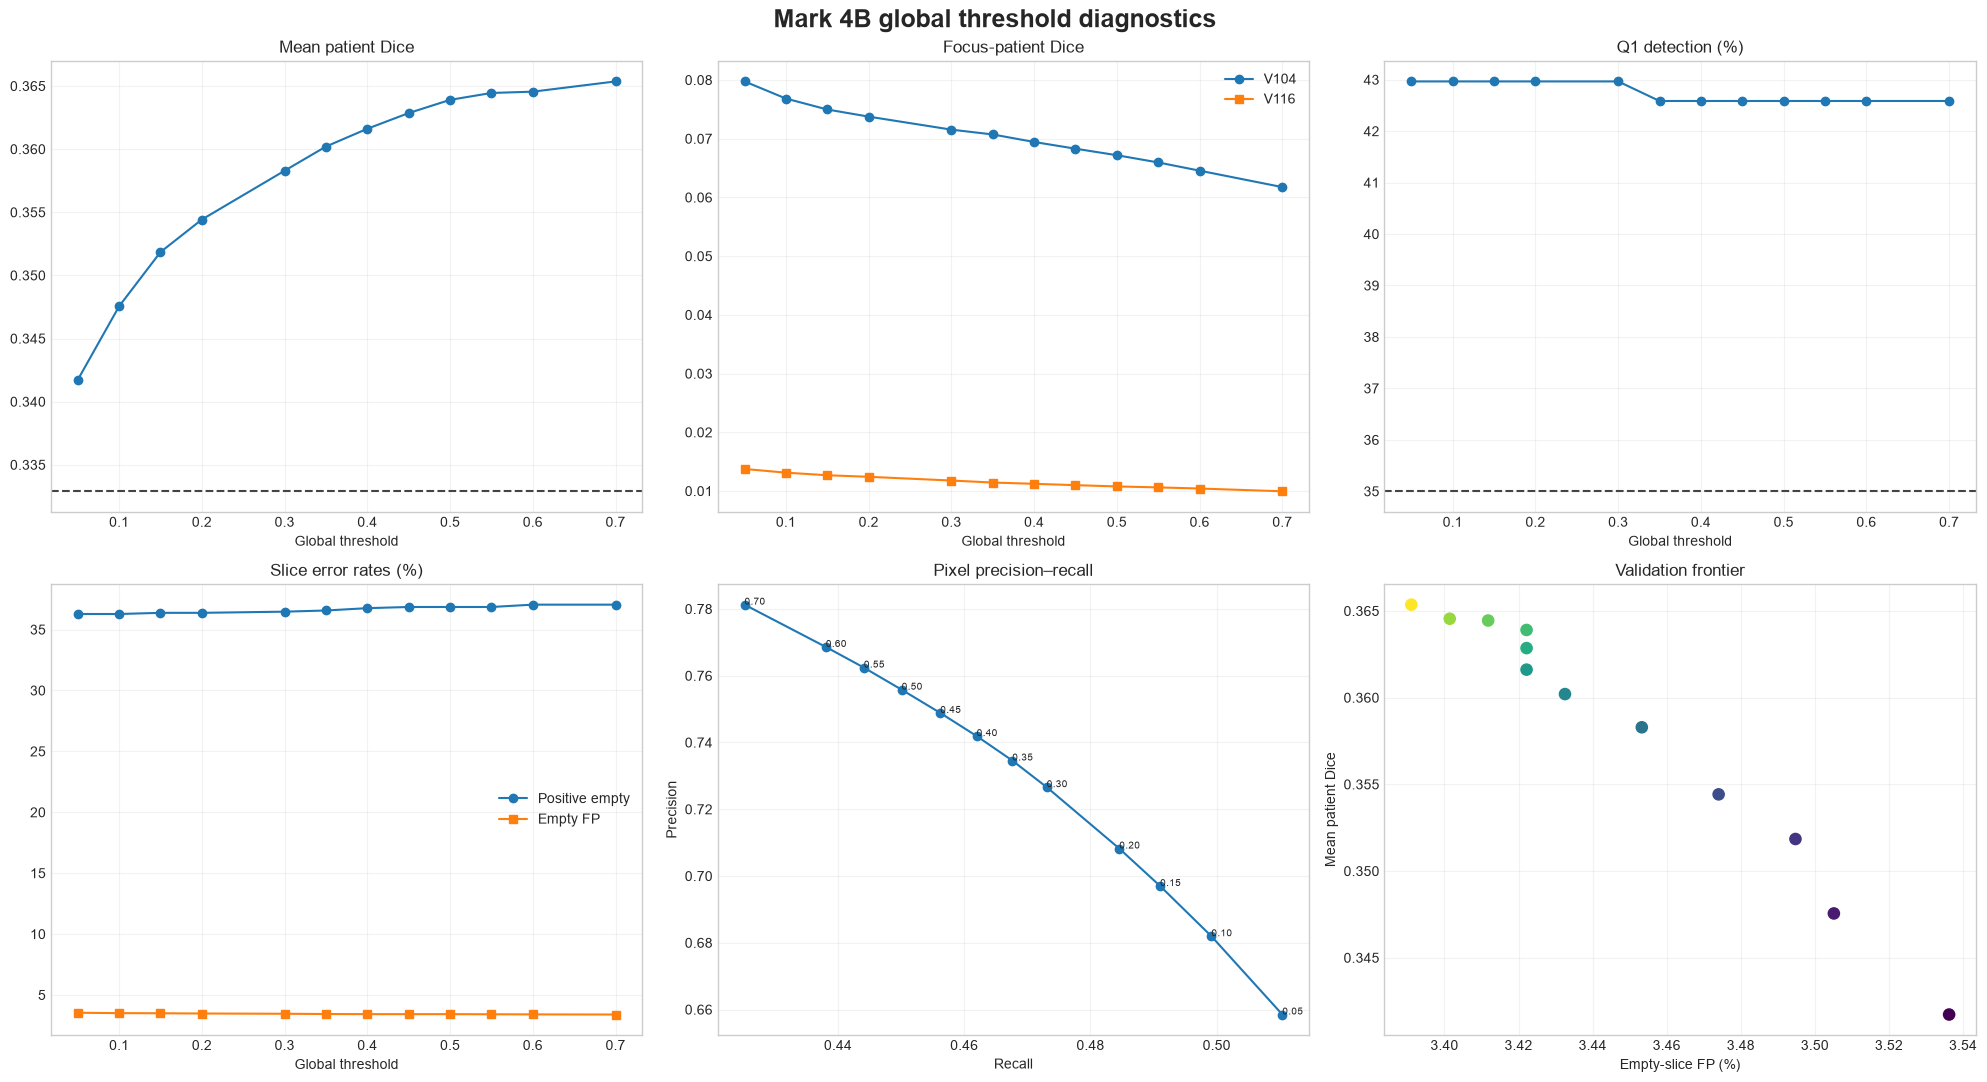

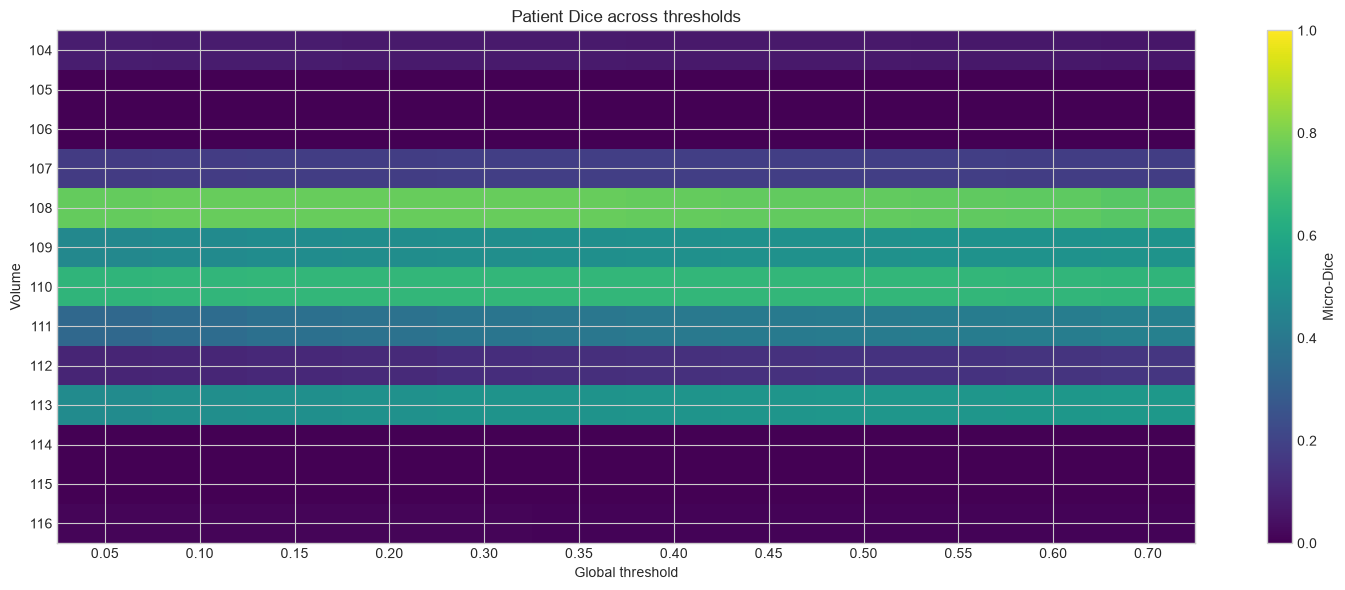

In [8]:
figure, axes = plt.subplots(2, 3, figsize=(20, 11))
axes[0, 0].plot(threshold_results["threshold"], threshold_results["mean_patient_dice"], marker="o")
axes[0, 0].axhline(CONTINUATION_TARGETS["mean_patient_dice"], linestyle="--", color="#444")
axes[0, 0].set_title("Mean patient Dice")
axes[0, 1].plot(threshold_results["threshold"], threshold_results["volume_104_dice"], marker="o", label="V104")
axes[0, 1].plot(threshold_results["threshold"], threshold_results["volume_116_dice"], marker="s", label="V116")
axes[0, 1].set_title("Focus-patient Dice"); axes[0, 1].legend()
axes[0, 2].plot(threshold_results["threshold"], threshold_results["q1_detected_pct"], marker="o")
axes[0, 2].axhline(CONTINUATION_TARGETS["q1_detected_pct"], linestyle="--", color="#444")
axes[0, 2].set_title("Q1 detection (%)")
axes[1, 0].plot(threshold_results["threshold"], threshold_results["positive_predicted_empty_pct"], marker="o", label="Positive empty")
axes[1, 0].plot(threshold_results["threshold"], threshold_results["empty_slice_false_positive_pct"], marker="s", label="Empty FP")
axes[1, 0].legend(); axes[1, 0].set_title("Slice error rates (%)")
axes[1, 1].plot(threshold_results["pixel_recall"], threshold_results["pixel_precision"], marker="o")
for row in threshold_results.itertuples():
    axes[1, 1].annotate(f"{row.threshold:.2f}", (row.pixel_recall, row.pixel_precision), fontsize=7)
axes[1, 1].set_xlabel("Recall"); axes[1, 1].set_ylabel("Precision")
axes[1, 1].set_title("Pixel precision–recall")
axes[1, 2].scatter(
    threshold_results["empty_slice_false_positive_pct"],
    threshold_results["mean_patient_dice"],
    c=threshold_results["threshold"], cmap="viridis", s=65,
)
axes[1, 2].set_xlabel("Empty-slice FP (%)")
axes[1, 2].set_ylabel("Mean patient Dice")
axes[1, 2].set_title("Validation frontier")
for axis in axes.flat:
    axis.set_xlabel(axis.get_xlabel() or "Global threshold")
    axis.grid(alpha=0.25)
figure.suptitle("Mark 4B global threshold diagnostics", fontsize=18, weight="bold")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "calibration_frontier_dashboard.png", dpi=170, bbox_inches="tight")
plt.show()

heatmap = threshold_patient_metrics.pivot(
    index="volume_id", columns="threshold", values="micro_dice"
)
figure, axis = plt.subplots(figsize=(15, 6))
image = axis.imshow(heatmap, vmin=0, vmax=1, cmap="viridis", aspect="auto")
axis.set_xticks(range(len(heatmap.columns)), [f"{value:.2f}" for value in heatmap.columns])
axis.set_yticks(range(len(heatmap.index)), heatmap.index)
axis.set_xlabel("Global threshold"); axis.set_ylabel("Volume")
axis.set_title("Patient Dice across thresholds")
figure.colorbar(image, ax=axis, label="Micro-Dice")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "patient_threshold_heatmap.png", dpi=170, bbox_inches="tight")
plt.show()

### 8. Inspect V104/V116 localization and probability populations

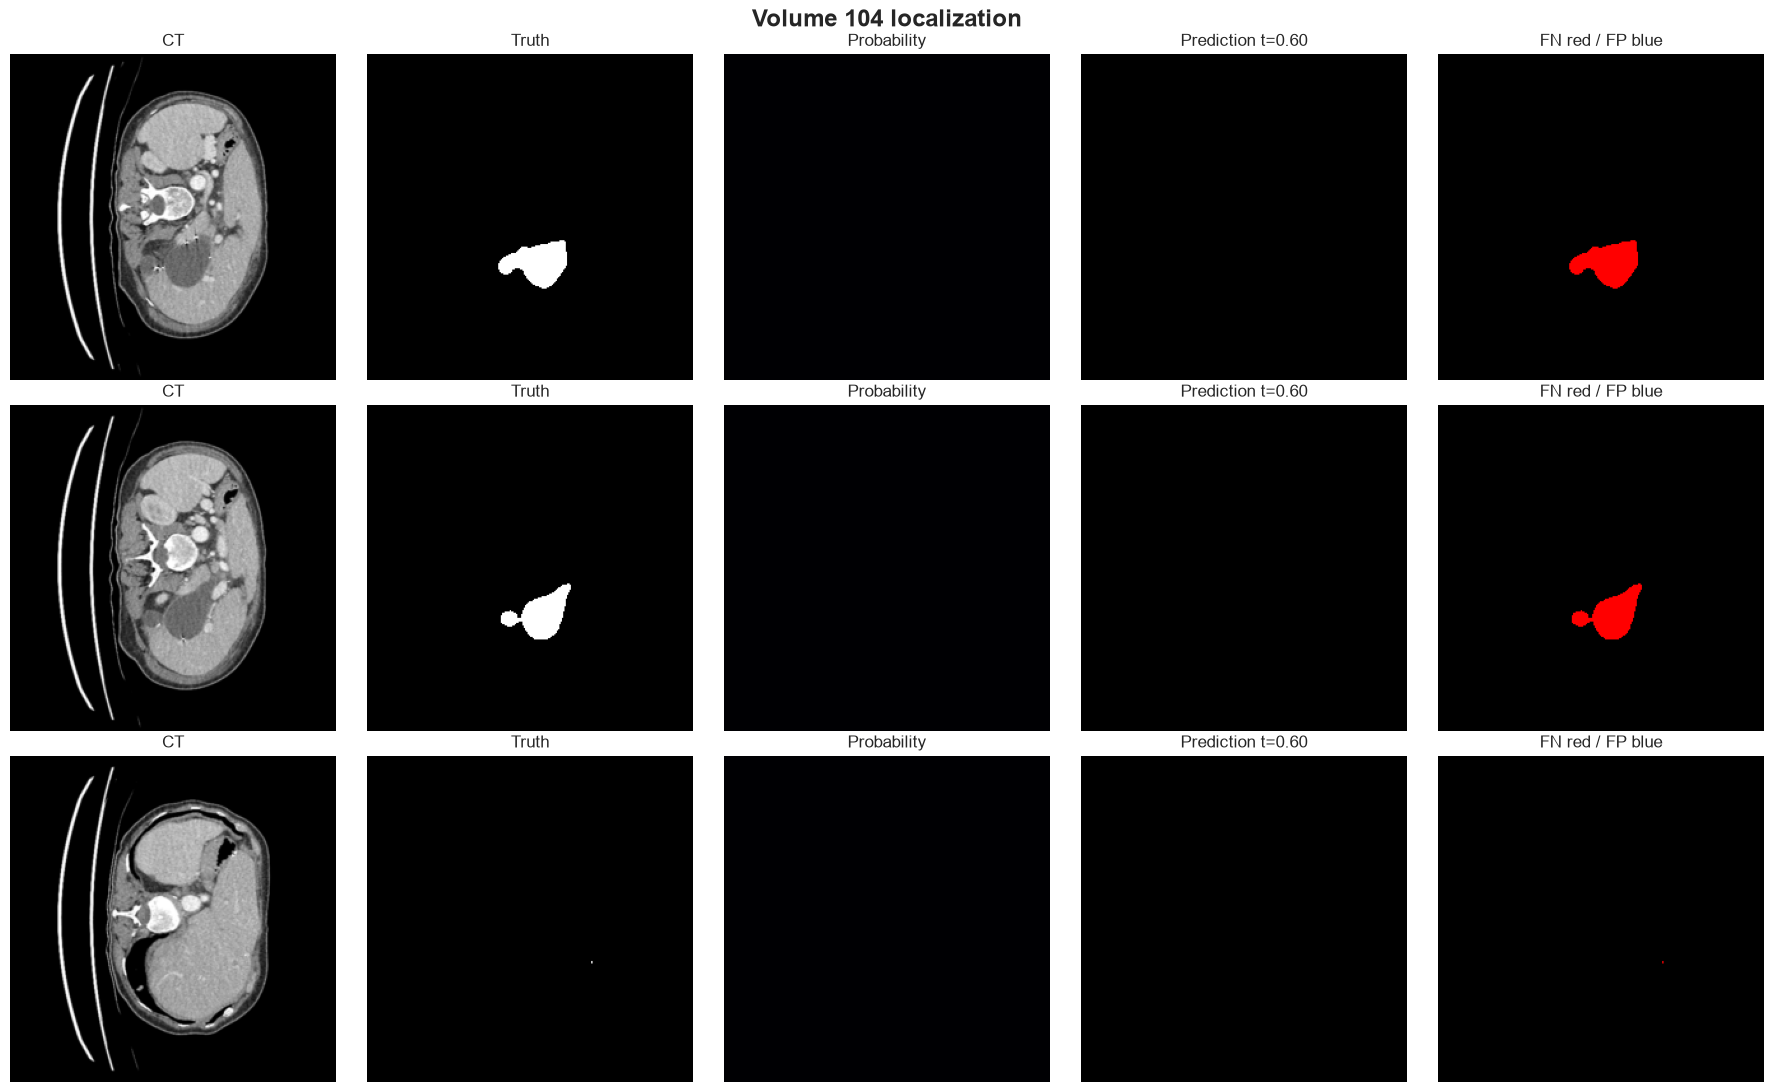

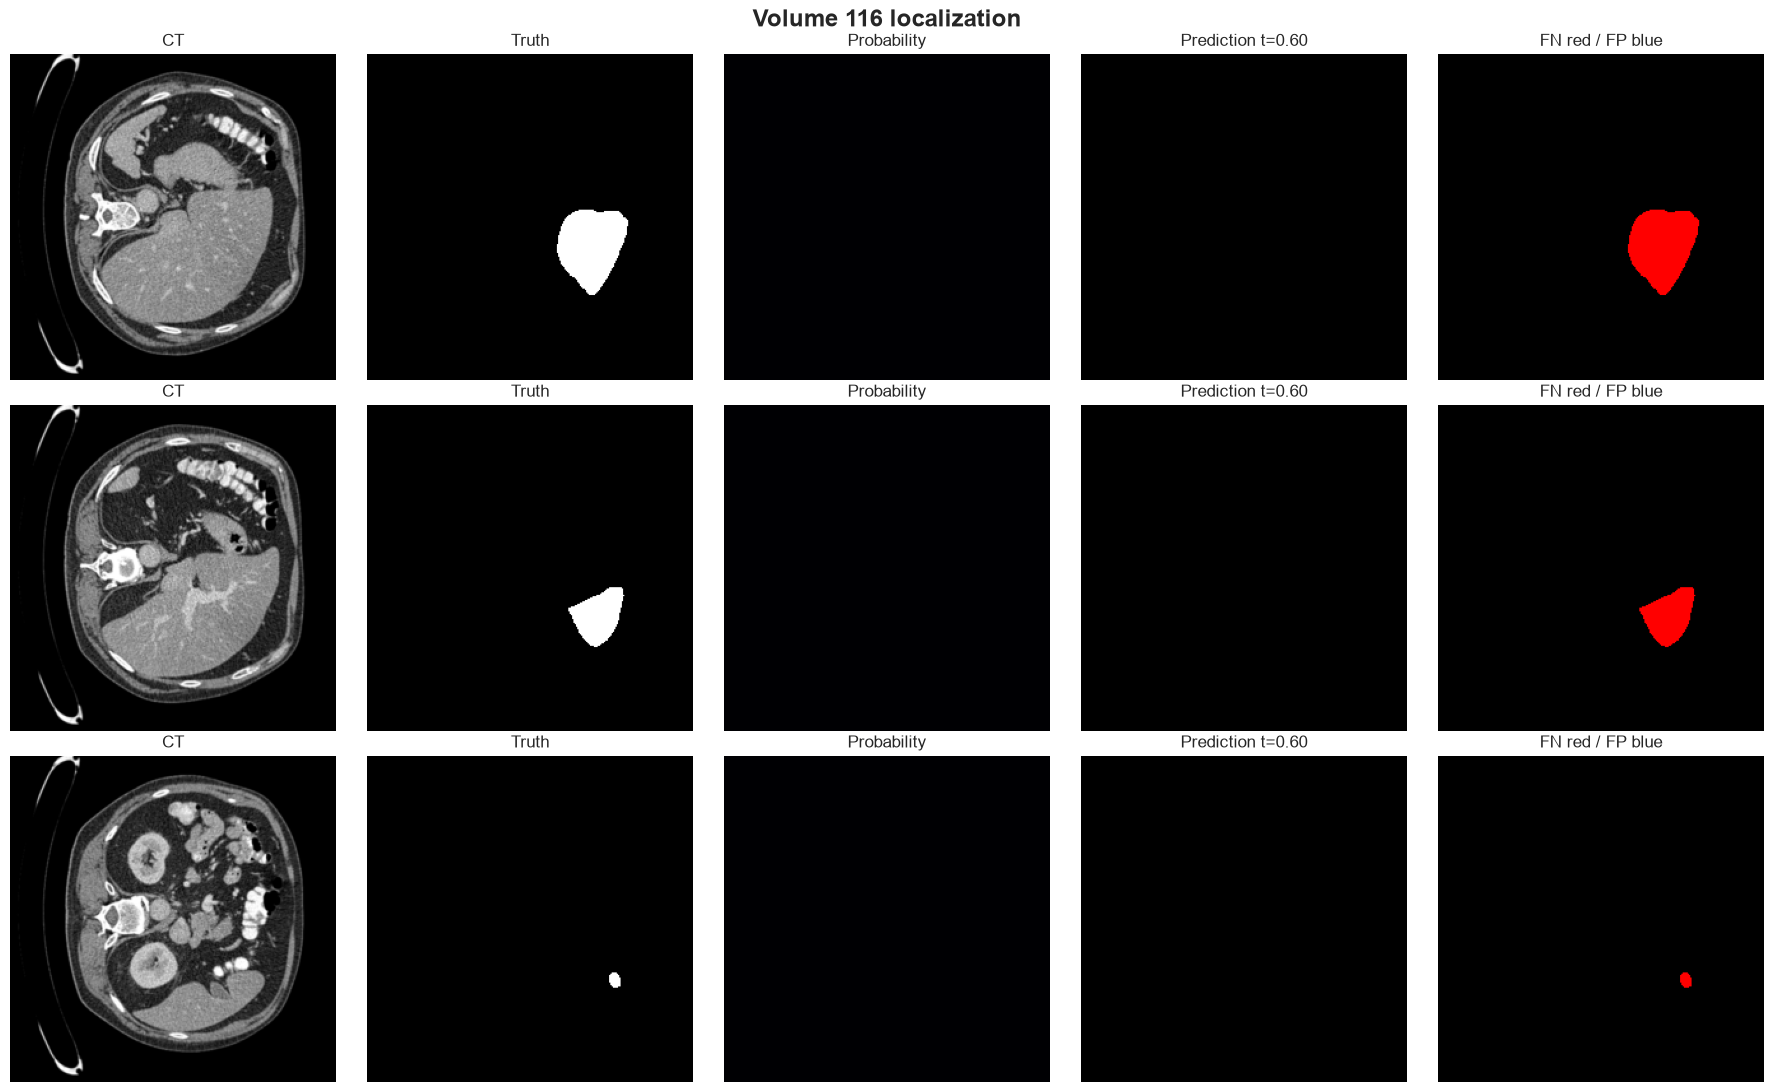

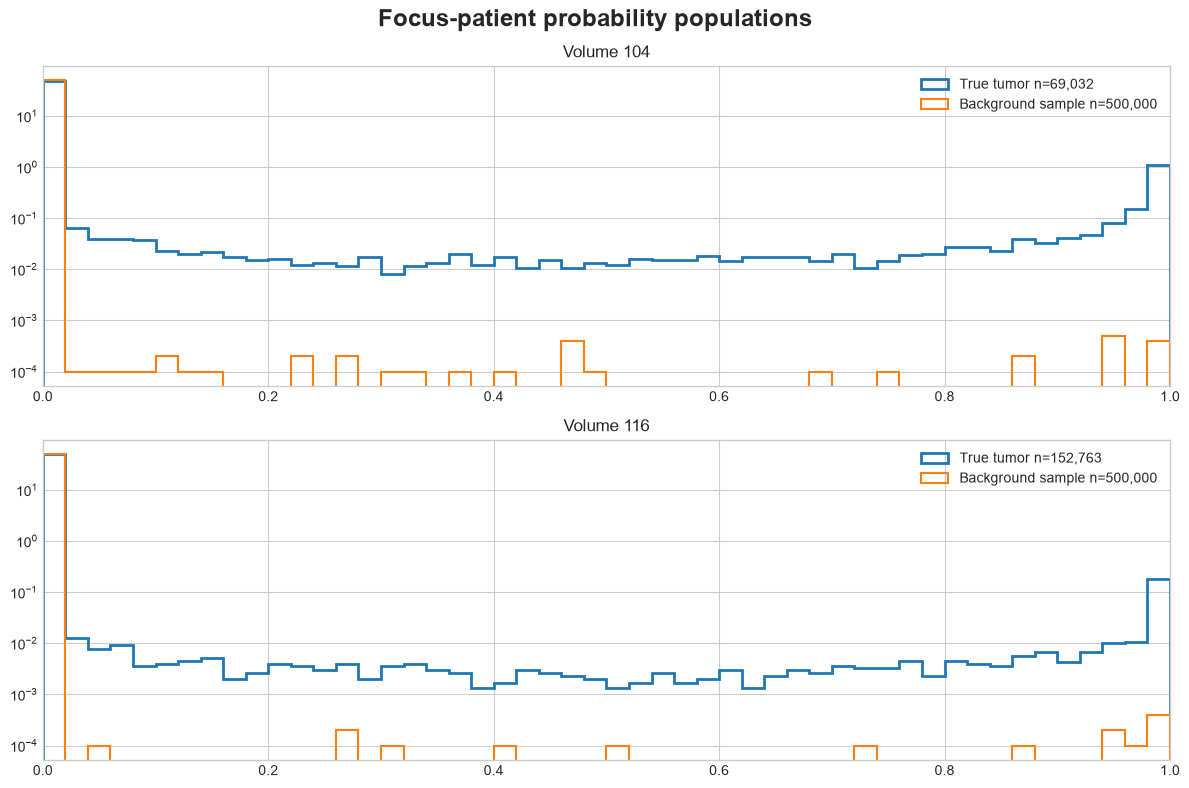

In [9]:
def load_full_image(sample_id):
    row = validation_manifest.loc[validation_manifest["sample_id"].eq(sample_id)].iloc[0]
    with Image.open(DATASET_ROOT / row.image_path) as handle:
        return np.asarray(handle.convert("L"), dtype=np.float32) / 255.0

def localization_panel(volume_id):
    item = probability_cache[volume_id]
    sizes = item["tumor_truth"].sum(axis=(1, 2))
    positive_indices = np.flatnonzero(sizes > 0)
    chosen = list(dict.fromkeys([
        int(positive_indices[np.argmax(sizes[positive_indices])]),
        int(positive_indices[len(positive_indices) // 2]),
        int(positive_indices[np.argmin(sizes[positive_indices])]),
    ]))
    figure, axes = plt.subplots(len(chosen), 5, figsize=(18, 3.7 * len(chosen)))
    if len(chosen) == 1: axes = axes[None, :]
    threshold = float(selected["threshold"])
    for row_axes, index in zip(axes, chosen):
        sample_id = str(item["sample_id"][index])
        image = load_full_image(sample_id)
        truth = item["tumor_truth"][index].astype(bool)
        probability = item["tumor_probability"][index].astype(np.float32)
        prediction = probability >= threshold
        error = np.zeros((*truth.shape, 3), dtype=np.float32)
        error[truth & ~prediction, 0] = 1
        error[prediction & ~truth, 2] = 1
        panels = [
            (image, "CT", "gray"), (truth, "Truth", "gray"),
            (probability, "Probability", "magma"),
            (prediction, f"Prediction t={threshold:.2f}", "gray"),
            (error, "FN red / FP blue", None),
        ]
        for axis, (panel, title, cmap) in zip(row_axes, panels):
            axis.imshow(panel, cmap=cmap, vmin=0 if panel.ndim == 2 else None,
                        vmax=1 if panel.ndim == 2 else None)
            axis.set_title(title); axis.axis("off")
        row_axes[0].set_ylabel(sample_id, fontsize=8)
    figure.suptitle(f"Volume {volume_id} localization", fontsize=17, weight="bold")
    figure.tight_layout()
    figure.savefig(OUTPUT_DIR / f"localization_volume_{volume_id}.png", dpi=170, bbox_inches="tight")
    plt.show()

localization_panel(104)
localization_panel(116)

figure, axes = plt.subplots(2, 1, figsize=(12, 8))
bins = np.linspace(0, 1, 51)
rng = np.random.default_rng(SEED)
for axis, volume_id in zip(axes, [104, 116]):
    item = probability_cache[volume_id]
    probability = item["tumor_probability"].astype(np.float32)
    truth = item["tumor_truth"].astype(bool)
    true_values = probability[truth]
    background = probability[~truth]
    if background.size > 500_000:
        background = rng.choice(background, 500_000, replace=False)
    axis.hist(true_values, bins=bins, density=True, histtype="step", linewidth=2, label=f"True tumor n={len(true_values):,}")
    axis.hist(background, bins=bins, density=True, histtype="step", linewidth=1.5, label=f"Background sample n={len(background):,}")
    axis.set_yscale("log"); axis.set_xlim(0, 1)
    axis.set_title(f"Volume {volume_id}"); axis.legend()
figure.suptitle("Focus-patient probability populations", fontsize=17, weight="bold")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "focus_probability_histograms.png", dpi=170, bbox_inches="tight")
plt.show()

### 9. Bootstrap uncertainty for the selected configuration

In [10]:
selected_patients = threshold_patient_metrics.loc[
    threshold_patient_metrics["threshold"].eq(float(selected["threshold"]))
    & threshold_patient_metrics["true_pixels"].gt(0)
].copy()
values = selected_patients["micro_dice"].to_numpy()
rng = np.random.default_rng(SEED)
bootstrap_means = np.array([
    rng.choice(values, size=len(values), replace=True).mean()
    for _ in range(BOOTSTRAP_ITERATIONS)
])
bootstrap = pd.DataFrame([{
    "threshold": float(selected["threshold"]),
    "patients": len(values),
    "iterations": BOOTSTRAP_ITERATIONS,
    "mean_dice_p2_5": np.percentile(bootstrap_means, 2.5),
    "mean_dice_p50": np.percentile(bootstrap_means, 50),
    "mean_dice_p97_5": np.percentile(bootstrap_means, 97.5),
    "original_median": np.median(values),
    "original_q25": np.percentile(values, 25),
    "original_q75": np.percentile(values, 75),
}])
bootstrap.to_csv(OUTPUT_DIR / "bootstrap_confidence_intervals.csv", index=False)
display(bootstrap)

,threshold,patients,iterations,mean_dice_p2_5,mean_dice_p50,mean_dice_p97_5,original_median,original_q25,original_q75
0,0.6,9,1000,0.189341,0.368614,0.531381,0.424839,0.150339,0.52821


## Takeaways

### 10. Write the Mark 4B decision gate

In [11]:
continuation_passed = bool(selected["all_continuation_targets_passed"])
final_passed = bool(selected["all_final_targets_passed"])
baseline_050 = threshold_results.loc[
    np.isclose(threshold_results["threshold"], 0.50)
].iloc[0]

if continuation_passed:
    decision = "FREEZE_THRESHOLD_AND_PROCEED_TO_BOUNDED_EPOCH_10_CONTINUATION"
    next_notebook = "mark_5_two_stage_bounded_continuation"
elif (
    selected["positive_predicted_empty_pct"] <= CONTINUATION_TARGETS["positive_predicted_empty_pct"]
    and selected["empty_slice_false_positive_pct"] > CONTINUATION_TARGETS["empty_slice_false_positive_pct"]
):
    decision = "REVISE_SAMPLING_OR_STABLE_RECALL_OBJECTIVE"
    next_notebook = "mark_4c_sampling_loss_ablation"
else:
    decision = "PROBABILITIES_REMAIN_INSUFFICIENT_REVISE_INPUT_OR_OBJECTIVE"
    next_notebook = "mark_4c_two_channel_or_recall_ablation"

gate = {
    "status": "mark_4b_diagnostic_complete",
    "selected_global_threshold": float(selected["threshold"]),
    "continuation_gate_passed": continuation_passed,
    "final_validation_gate_passed": final_passed,
    "selected_metrics": {
        key: float(selected[key]) for key in CONTINUATION_TARGETS
    },
    "targets_passed": int(selected["continuation_targets_passed"]),
    "threshold_0_50_metrics": {
        key: float(baseline_050[key]) for key in CONTINUATION_TARGETS
    },
    "bootstrap": bootstrap.iloc[0].to_dict(),
    "decision": decision,
    "next_notebook": next_notebook,
    "manifest_sha256": EXPECTED_MANIFEST_SHA256,
    "checkpoint_sha256": checkpoint_hash,
    "test_images_accessed": False,
}
(OUTPUT_DIR / "mark_4b_gate_result.json").write_text(
    json.dumps(gate, indent=2), encoding="utf-8"
)
expected_actual = pd.DataFrame([
    {
        "metric": key, "actual": selected[key],
        "continuation_target": CONTINUATION_TARGETS[key],
        "final_target": FINAL_TARGETS[key],
    }
    for key in CONTINUATION_TARGETS
])
expected_actual.to_csv(OUTPUT_DIR / "expected_vs_actual.csv", index=False)
display(pd.DataFrame([gate]).T.rename(columns={0: "value"}))
display(expected_actual)
print(decision)

,value
status,mark_4b_diagnostic_complete
selected_global_threshold,0.6
continuation_gate_passed,False
final_validation_gate_passed,False
selected_metrics,"{'mean_patient_dice': 0.3645500967728056, 'vol..."
targets_passed,5
threshold_0_50_metrics,"{'mean_patient_dice': 0.363902230361049, 'volu..."
bootstrap,"{'threshold': 0.6000000238418579, 'patients': ..."
decision,PROBABILITIES_REMAIN_INSUFFICIENT_REVISE_INPUT...
next_notebook,mark_4c_two_channel_or_recall_ablation


,metric,actual,continuation_target,final_target
0,mean_patient_dice,0.364550,0.3329,0.406915
1,volume_104_dice,0.064557,0.0500,0.500000
2,volume_116_dice,0.010424,0.0100,0.050000
3,q1_detected_pct,42.585551,35.0000,45.000000
4,positive_predicted_empty_pct,37.044146,35.0000,20.000000
5,empty_slice_false_positive_pct,3.401431,20.0000,15.000000


PROBABILITIES_REMAIN_INSUFFICIENT_REVISE_INPUT_OR_OBJECTIVE


### Interpretation contract

- Passing freezes one global threshold and permits only a bounded epoch-5-to-10 continuation.
- Calibration does not replace the final validation targets.
- If no threshold passes, do not tune thresholds by patient or lesion size.
- A training revision must retain the same ROI geometry, patient split, full-image mapping,
  provenance, and test lock.
- Test evaluation remains prohibited until every final validation target passes simultaneously.